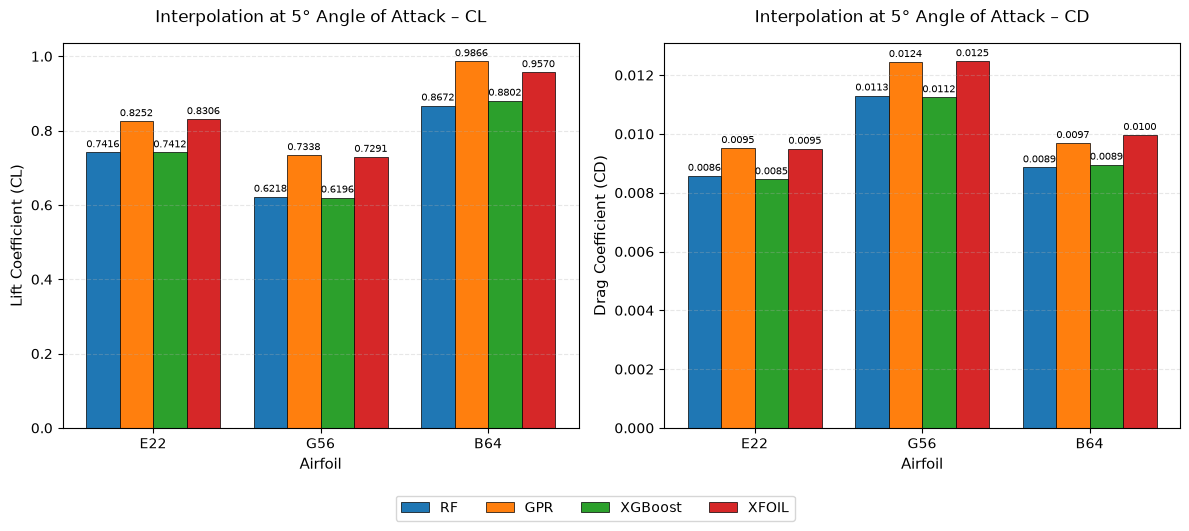

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Data as given in the table
airfoils = ['E22', 'G56', 'B64']

# CL values for each airfoil and each model
cl_data = {
    'RF':     [0.7416, 0.6218, 0.8672],
    'GPR':    [0.8252, 0.7338, 0.9866],
    'XGBoost':[0.7412, 0.6196, 0.8802],
    'XFOIL':  [0.8306, 0.7291, 0.9570]
}

# CD values for each airfoil and each model
cd_data = {
    'RF':     [0.008571, 0.011301, 0.008858],
    'GPR':    [0.009515, 0.012441, 0.009686],
    'XGBoost':[0.008452, 0.011242, 0.008949],
    'XFOIL':  [0.00949, 0.01247, 0.00996]
}

# Set up the plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Bar positions
x = np.arange(len(airfoils))  # positions for each airfoil group
width = 0.2  # width of each bar

# Simple, distinguishable colors
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # blue, orange, green, red

# --- Subplot 1: Lift Coefficient ---
for i, (model, values) in enumerate(cl_data.items()):
    offset = (i - 1.5) * width
    ax1.bar(x + offset, values, width, label=model, color=colors[i], edgecolor='black', linewidth=0.5)

ax1.set_xlabel('Airfoil', fontsize=11)
ax1.set_ylabel('Lift Coefficient (CL)', fontsize=11)
ax1.set_title('Interpolation at 5° Angle of Attack – CL', fontsize=12, pad=15)
ax1.set_xticks(x)
ax1.set_xticklabels(airfoils)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# --- Subplot 2: Drag Coefficient ---
for i, (model, values) in enumerate(cd_data.items()):
    offset = (i - 1.5) * width
    ax2.bar(x + offset, values, width, label=model, color=colors[i], edgecolor='black', linewidth=0.5)

ax2.set_xlabel('Airfoil', fontsize=11)
ax2.set_ylabel('Drag Coefficient (CD)', fontsize=11)
ax2.set_title('Interpolation at 5° Angle of Attack – CD', fontsize=12, pad=15)
ax2.set_xticks(x)
ax2.set_xticklabels(airfoils)
ax2.grid(axis='y', linestyle='--', alpha=0.3)

# Add numeric value on top of each bar with proper positioning
for ax in [ax1, ax2]:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.4f', fontsize=7,
                     rotation=0, padding=2,
                     label_type='edge')

# Create a single legend centered below both plots
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05),
           ncol=4, frameon=True, fancybox=True, shadow=False, fontsize=10)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15, top=0.92)  # Adjust top margin to prevent title-label clash
plt.show()

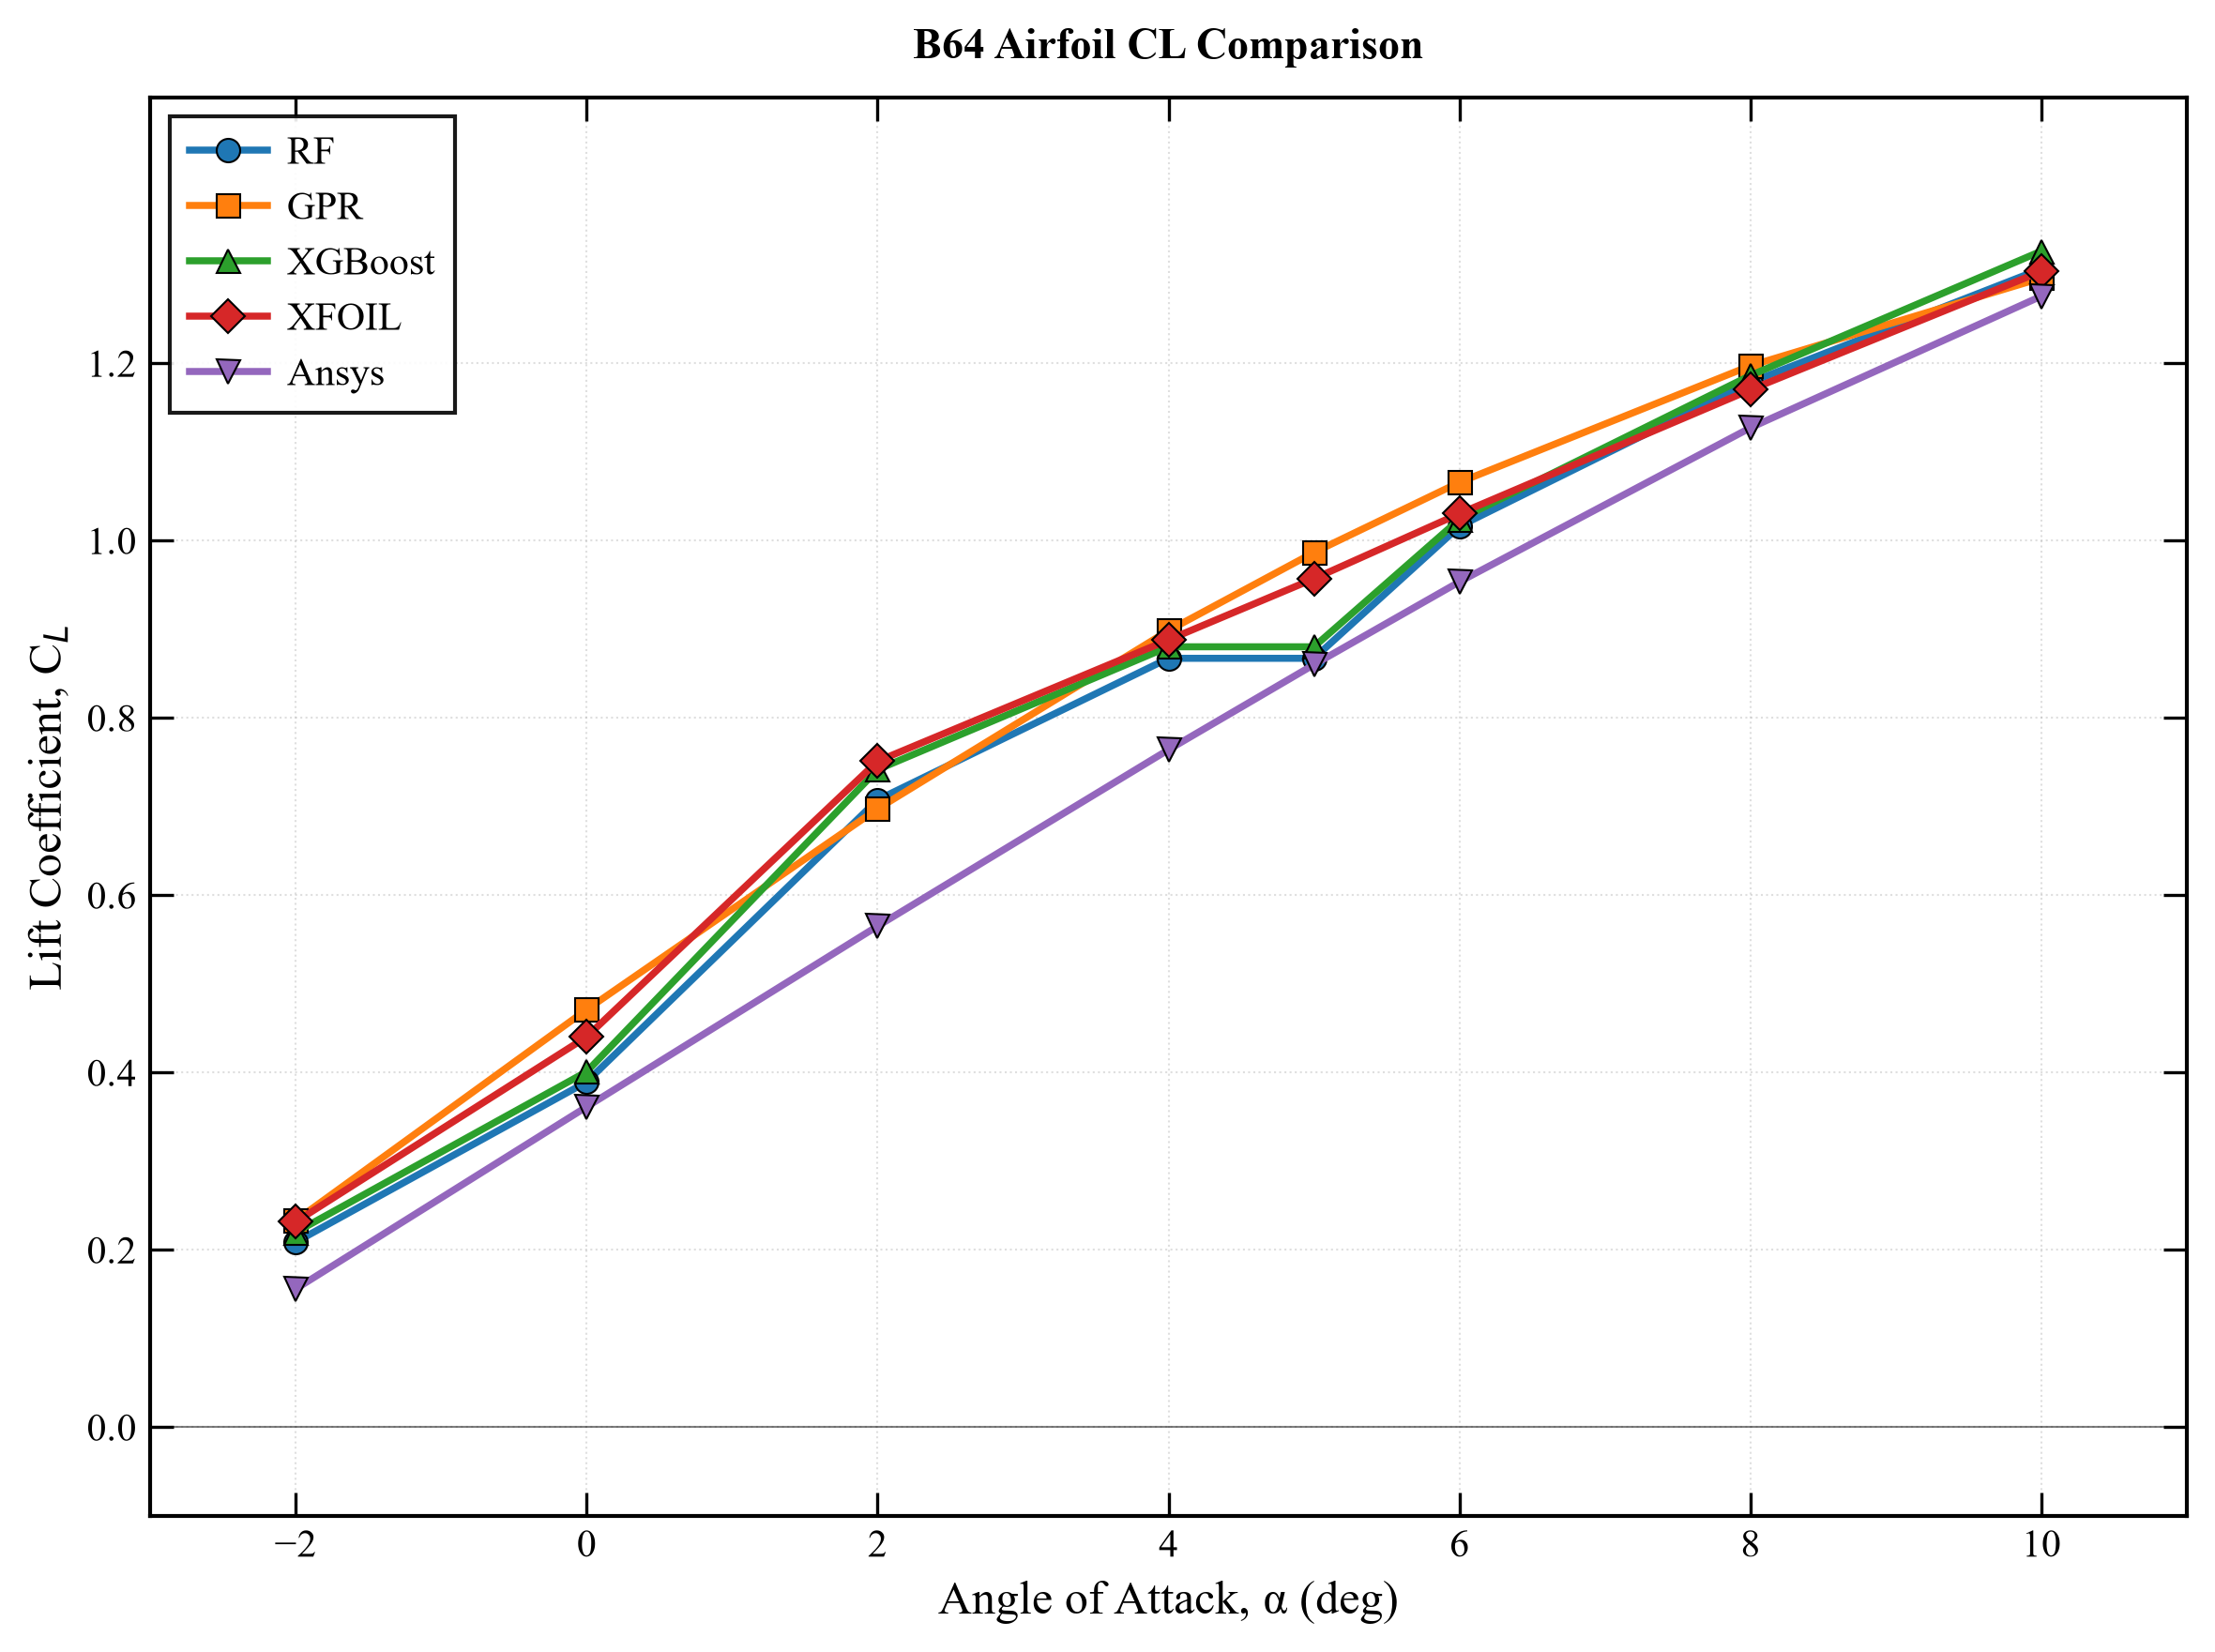

In [43]:
import matplotlib.pyplot as plt
import numpy as np

# Data from the table
AOA = [-2, 0, 2, 4, 5, 6, 8, 10]

data = {
    'RF':      [0.2087,	0.3894,	0.7075,	0.8672,	0.8672,	1.0161,	1.1785,	1.3065],
    'GPR':     [0.2331,	0.4709,	0.6974	,0.8985,	0.9866,	1.0657,	1.1972,	1.2961],
    'XGBoost': [0.2198,	0.4009,	0.7417,	0.8802,	0.8802,	1.024,	1.1862,	1.3265],
    'XFOIL':   [0.2316	,0.4402	,0.7511,	0.888,	0.957,	1.0304,	1.1701,	1.3036],
    'Ansys':   [0.1559	,0.3613,	0.5651,	0.7641,	0.8601,	0.9535,	1.1272,	1.2757]
}

# Scientific journal style settings
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'axes.linewidth': 1.0,
    'lines.linewidth': 1.5,
})

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Color palette suitable for journals (colorblind-friendly)
colors = {
    'RF': '#1f77b4',      # Blue
    'GPR': '#ff7f0e',     # Orange
    'XGBoost': '#2ca02c', # Green
    'XFOIL': '#d62728',   # Red
    'Ansys': '#9467bd'    # Purple
}

# Markers for different methods
markers = {
    'RF': 'o',
    'GPR': 's',
    'XGBoost': '^',
    'XFOIL': 'D',
    'Ansys': 'v'
}

# Plot each dataset
for method in data.keys():
    ax.plot(AOA, data[method],
            marker=markers[method],
            markersize=6,
            markeredgewidth=0.5,
            markeredgecolor='black',
            linewidth=1.8,
            color=colors[method],
            label=method,
            linestyle='-')

# Axis labels with proper formatting
ax.set_xlabel('Angle of Attack, α (deg)', fontsize=12, fontweight='normal')
ax.set_ylabel('Lift Coefficient, C$_L$', fontsize=12, fontweight='normal')

ax.set_title('B64 Airfoil CL Comparison', fontsize=11, pad=10, fontweight='bold')


# Set axis limits with padding
ax.set_xlim(-3, 11)
ax.set_ylim(-0.1, 1.5)

# Major and minor ticks
ax.set_xticks(np.arange(-2, 11, 2))
ax.set_yticks(np.arange(0, 1.4, 0.2))
ax.tick_params(direction='in', top=True, right=True, which='both')
ax.tick_params(axis='both', which='major', length=6, width=0.8)
ax.tick_params(axis='both', which='minor', length=3, width=0.5)

# Grid (light, scientific style)
ax.grid(True, linestyle=':', alpha=0.4, linewidth=0.5)

# Legend - scientific journal style
legend = ax.legend(loc='upper left',
                   frameon=True,
                   fancybox=False,
                   edgecolor='black',
                   framealpha=0.9,
                   borderpad=0.5,
                   handlelength=2.0,
                   handletextpad=0.5,
                   columnspacing=1.0)

# Add a subtle box around the plot
for spine in ax.spines.values():
    spine.set_linewidth(1.0)
    spine.set_color('black')

# Optional: Add horizontal line at CL=0 for reference
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)

# Adjust layout
plt.tight_layout()

# Save as high-quality figure (optional)
# plt.savefig('lift_curve_comparison.pdf', format='pdf', bbox_inches='tight')
# plt.savefig('lift_curve_comparison.png', format='png', bbox_inches='tight', dpi=300)

plt.show()

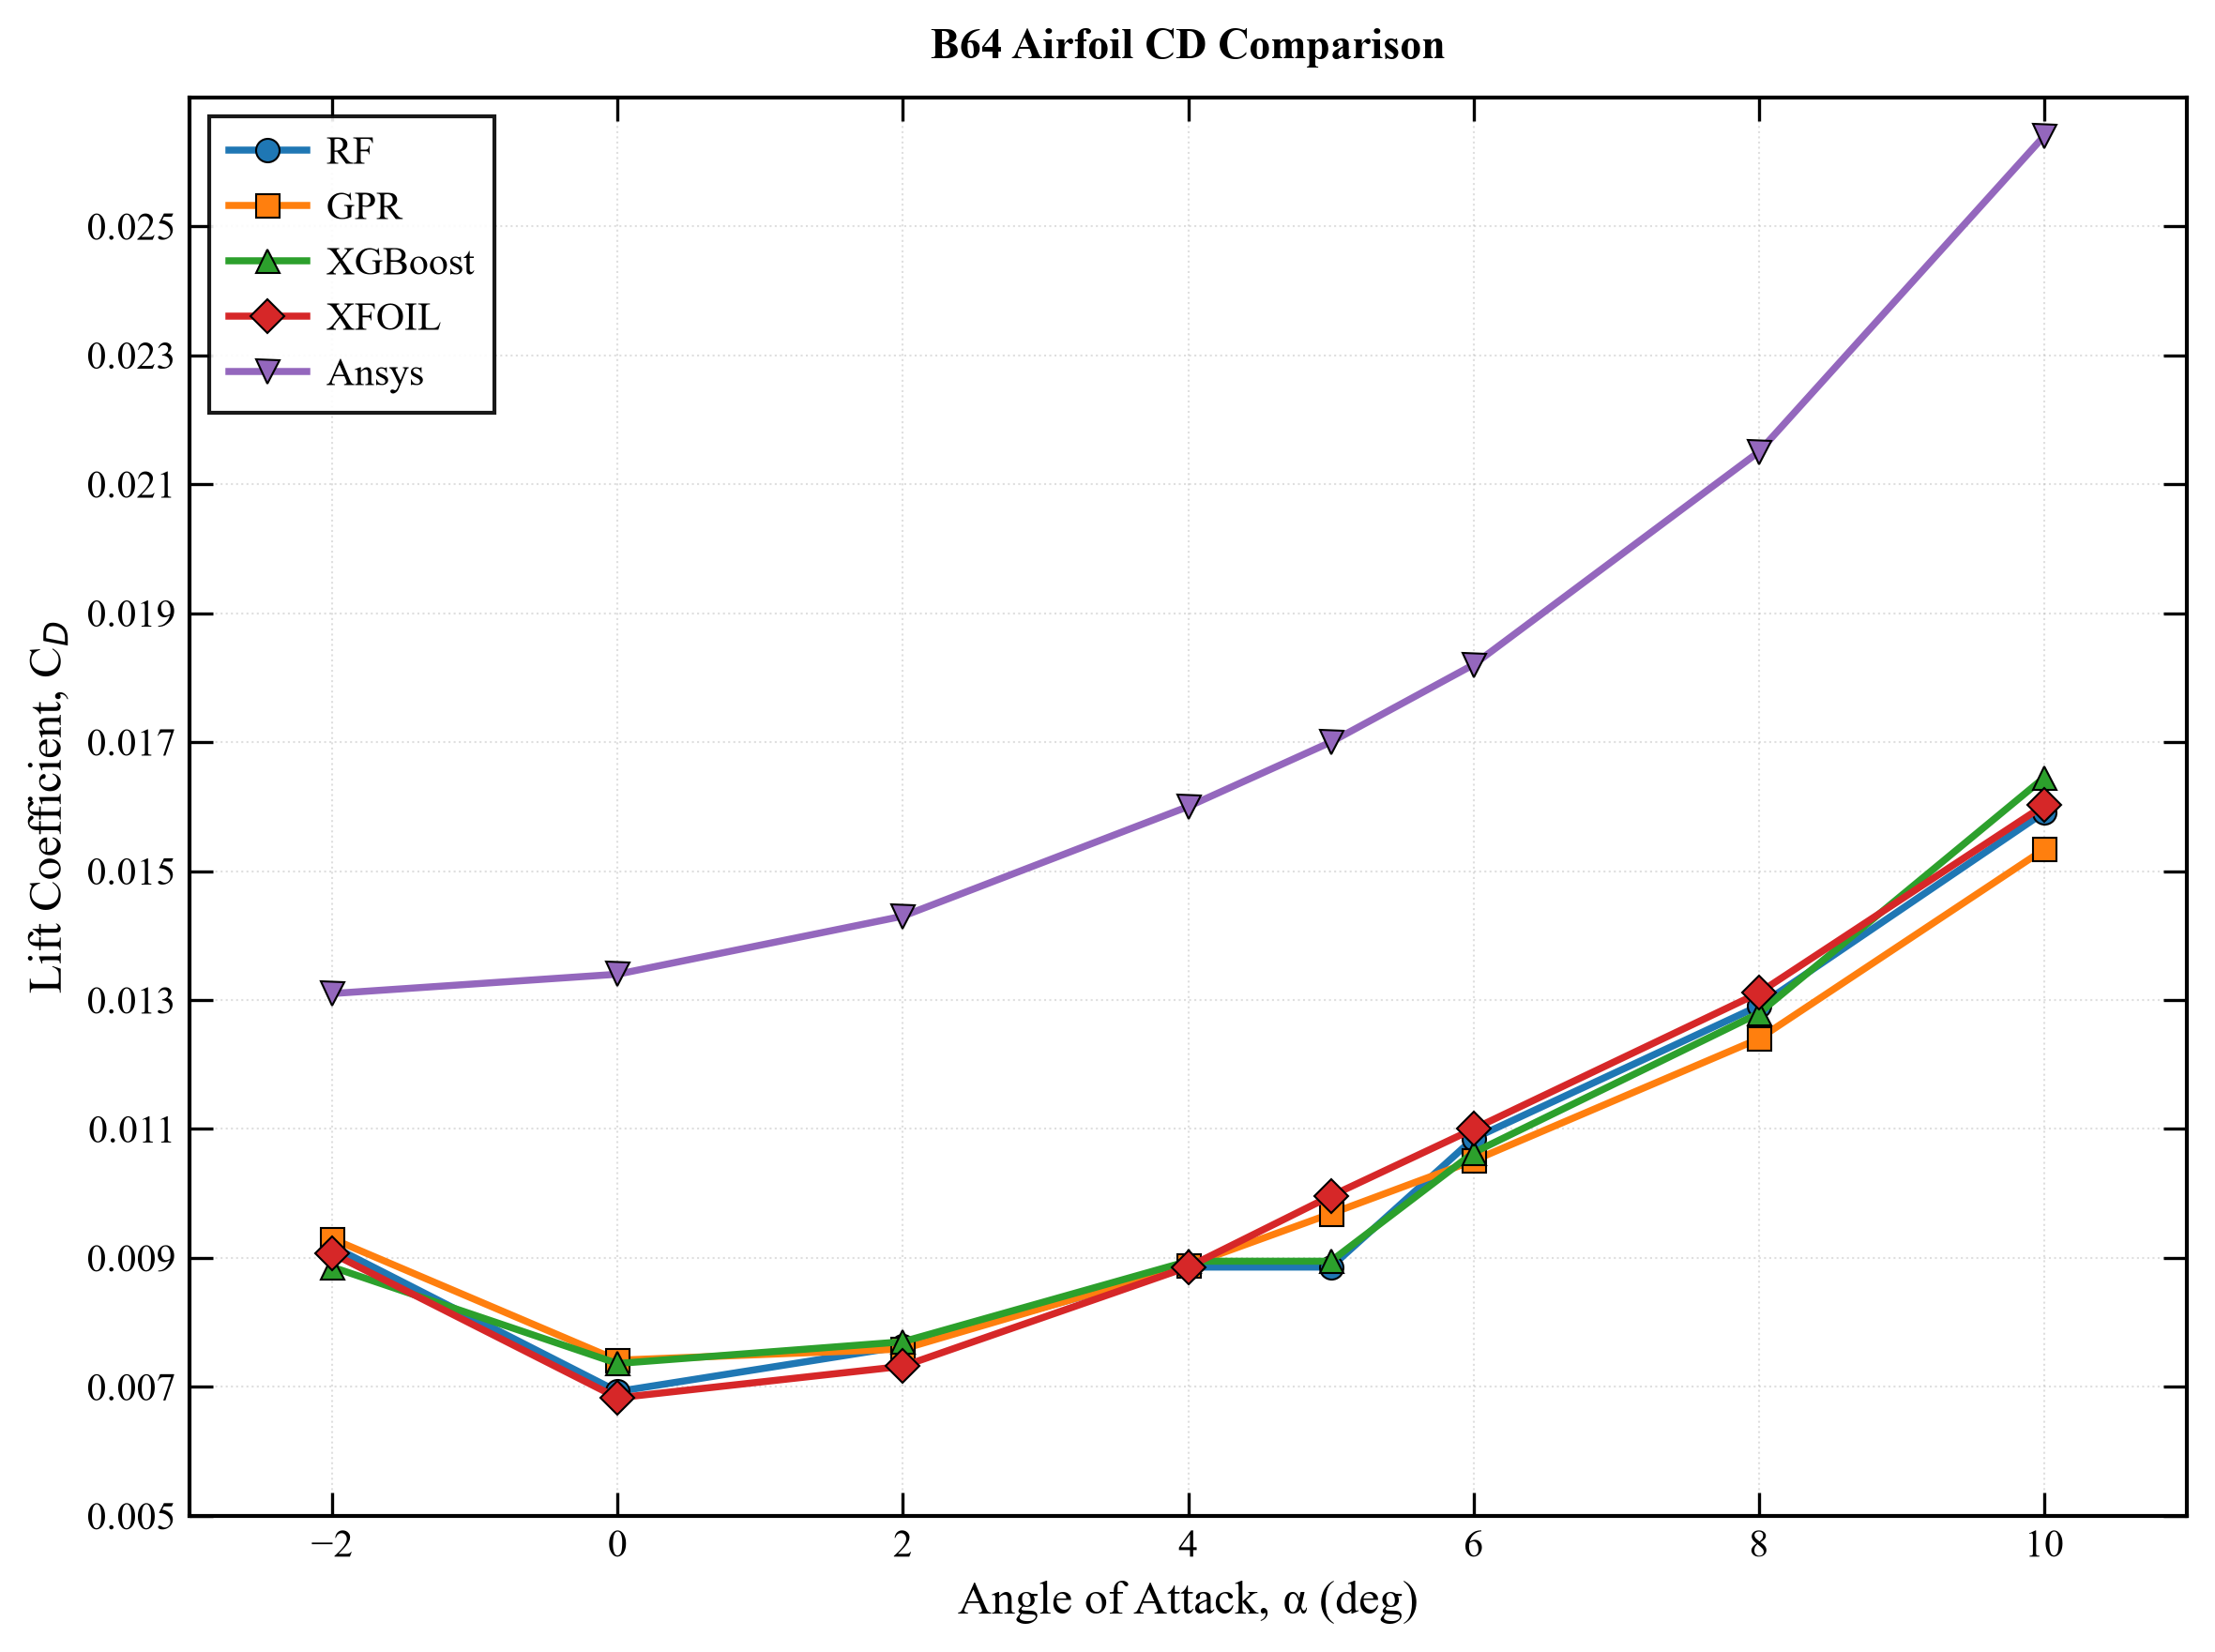

In [46]:
# _-----------------------------------CD-------------------------------
import matplotlib.pyplot as plt
import numpy as np

# Data from the table
AOA = [-2, 0, 2, 4, 5, 6, 8, 10]

data = {
    'RF':      [0.009182,	0.006928,	0.007629,	0.008858,	0.008858,	0.010851,	0.012908,	0.015911],
    'GPR':     [0.009297,	0.007414,	0.007587,	0.008886,	0.009686,	0.010509,	0.012398,	0.015336],
    'XGBoost': [0.008858,	0.007363,	0.0077,	0.008949,	0.008949,	0.010632,	0.012794,	0.016448],
    'XFOIL':   [0.00907,	0.00683	,0.00732	,0.00886,	0.00996	,0.011,	0.01311	,0.01602],
    'Ansys':   [0.0131	,0.0134	,0.0143	,0.0160	,0.0170	,0.0182	,0.0215,	0.0264]
}

# Scientific journal style settings
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'axes.linewidth': 1.0,
    'lines.linewidth': 1.5,
})

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Color palette suitable for journals (colorblind-friendly)
colors = {
    'RF': '#1f77b4',      # Blue
    'GPR': '#ff7f0e',     # Orange
    'XGBoost': '#2ca02c', # Green
    'XFOIL': '#d62728',   # Red
    'Ansys': '#9467bd'    # Purple
}

# Markers for different methods
markers = {
    'RF': 'o',
    'GPR': 's',
    'XGBoost': '^',
    'XFOIL': 'D',
    'Ansys': 'v'
}

# Plot each dataset
for method in data.keys():
    ax.plot(AOA, data[method],
            marker=markers[method],
            markersize=6,
            markeredgewidth=0.5,
            markeredgecolor='black',
            linewidth=1.8,
            color=colors[method],
            label=method,
            linestyle='-')

# Axis labels with proper formatting
ax.set_xlabel('Angle of Attack, α (deg)', fontsize=12, fontweight='normal')
ax.set_ylabel('Lift Coefficient, C$_D$', fontsize=12, fontweight='normal')

ax.set_title('B64 Airfoil CD Comparison', fontsize=11, pad=10, fontweight='bold')

# Set axis limits with padding
ax.set_xlim(-3, 11)
ax.set_ylim(0.005, 0.027)

# Major and minor ticks
ax.set_xticks(np.arange(-2, 11, 2))
ax.set_yticks(np.arange(0.005, 0.027, 0.002))
ax.tick_params(direction='in', top=True, right=True, which='both')
ax.tick_params(axis='both', which='major', length=6, width=0.8)
ax.tick_params(axis='both', which='minor', length=3, width=0.5)

# Grid (light, scientific style)
ax.grid(True, linestyle=':', alpha=0.4, linewidth=0.5)

# Legend - scientific journal style
legend = ax.legend(loc='upper left',
                   frameon=True,
                   fancybox=False,
                   edgecolor='black',
                   framealpha=0.9,
                   borderpad=0.5,
                   handlelength=2.0,
                   handletextpad=0.5,
                   columnspacing=1.0)

# Add a subtle box around the plot
for spine in ax.spines.values():
    spine.set_linewidth(1.0)
    spine.set_color('black')

# Optional: Add horizontal line at CL=0 for reference
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)

# Adjust layout
plt.tight_layout()

# Save as high-quality figure (optional)
# plt.savefig('lift_curve_comparison.pdf', format='pdf', bbox_inches='tight')
# plt.savefig('lift_curve_comparison.png', format='png', bbox_inches='tight', dpi=300)

plt.show()

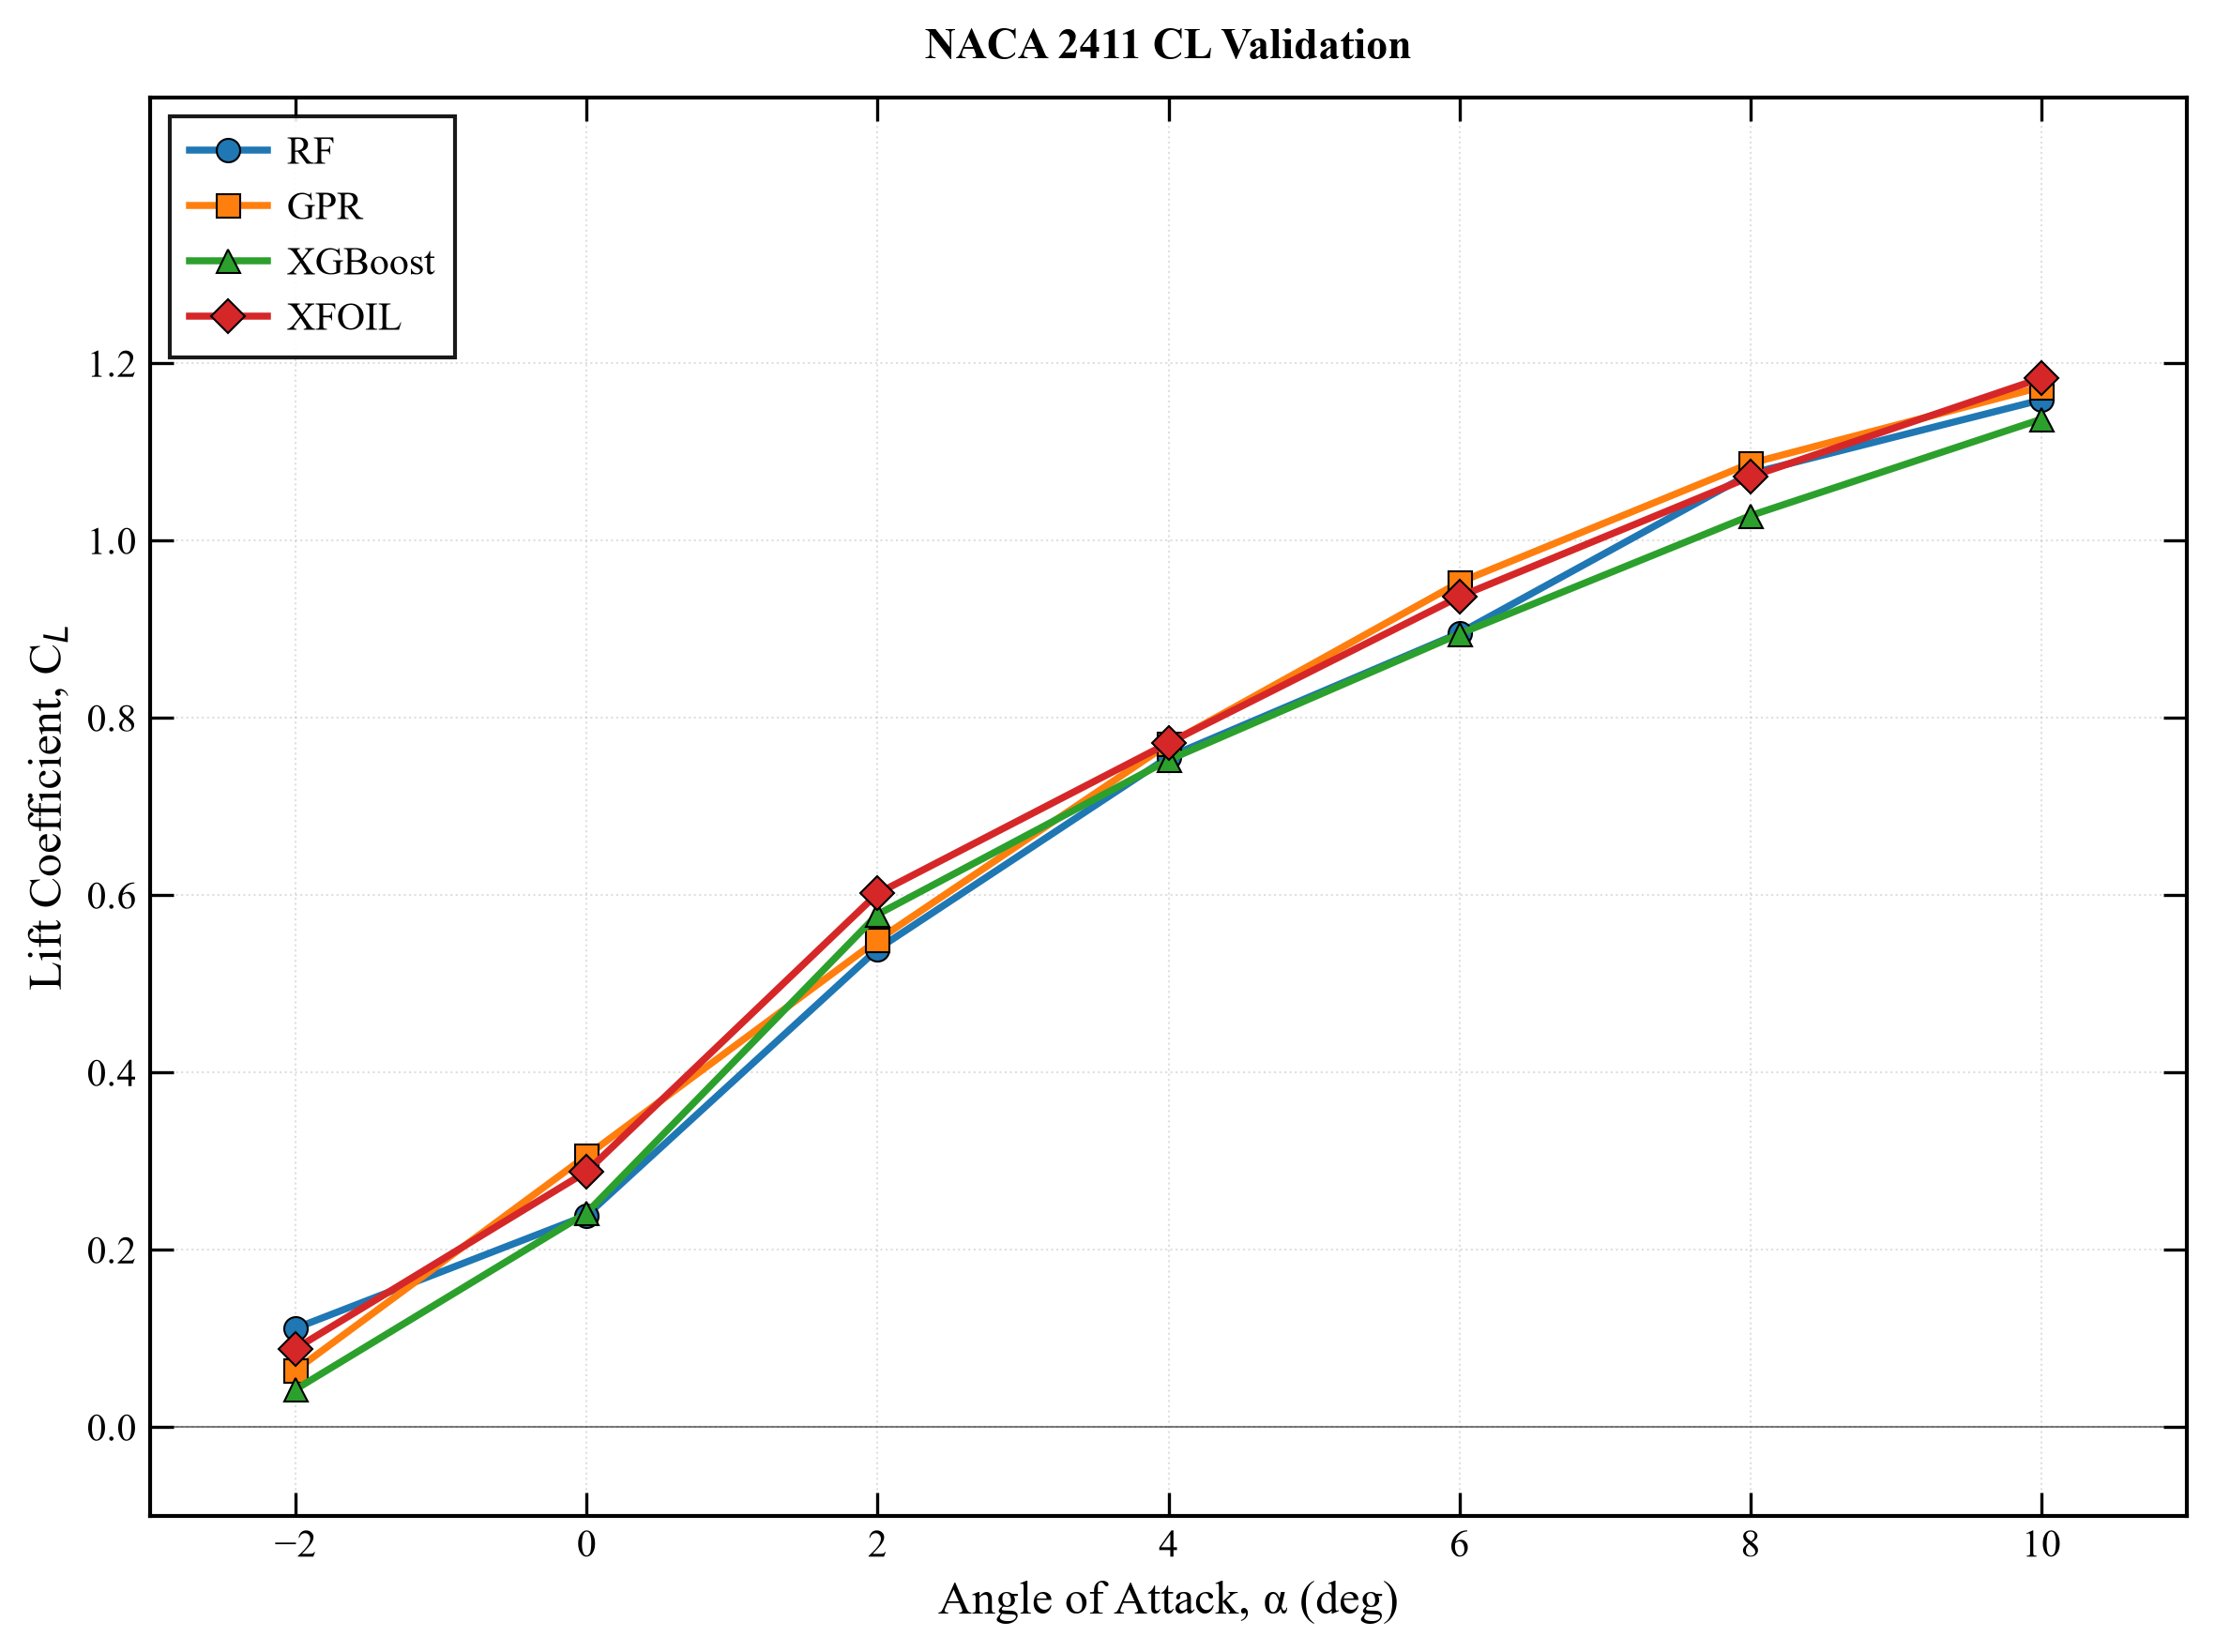

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Data from the table
AOA = [-2, 0, 2, 4, 6, 8, 10]

data = {
    'RF':      [0.1116,	0.2388,	0.5392,	0.7559,	0.8957,	1.0756,	1.1587],
    'GPR':     [0.0643,	0.3061,	0.5494,	0.7707,	0.9529,	1.0871,	1.1732],
    'XGBoost': [0.0427,	0.2417,	0.5783,	0.7525,0.8947,	1.0281,	1.1369],
    'XFOIL':   [0.0887,	0.2882	,0.602,	0.7717	,0.9368	,1.072,	1.1832],
}

# Scientific journal style settings
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'axes.linewidth': 1.0,
    'lines.linewidth': 1.5,
})

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Color palette suitable for journals (colorblind-friendly)
colors = {
    'RF': '#1f77b4',      # Blue
    'GPR': '#ff7f0e',     # Orange
    'XGBoost': '#2ca02c', # Green
    'XFOIL': '#d62728',   # Red
}

# Markers for different methods
markers = {
    'RF': 'o',
    'GPR': 's',
    'XGBoost': '^',
    'XFOIL': 'D',
}

# Plot each dataset
for method in data.keys():
    ax.plot(AOA, data[method],
            marker=markers[method],
            markersize=6,
            markeredgewidth=0.5,
            markeredgecolor='black',
            linewidth=1.8,
            color=colors[method],
            label=method,
            linestyle='-')

# Axis labels with proper formatting
ax.set_xlabel('Angle of Attack, α (deg)', fontsize=12, fontweight='normal')
ax.set_ylabel('Lift Coefficient, C$_L$', fontsize=12, fontweight='normal')

ax.set_title('NACA 2411 CL Validation', fontsize=11, pad=10, fontweight='bold')


# Set axis limits with padding
ax.set_xlim(-3, 11)
ax.set_ylim(-0.1, 1.5)

# Major and minor ticks
ax.set_xticks(np.arange(-2, 11, 2))
ax.set_yticks(np.arange(0, 1.4, 0.2))
ax.tick_params(direction='in', top=True, right=True, which='both')
ax.tick_params(axis='both', which='major', length=6, width=0.8)
ax.tick_params(axis='both', which='minor', length=3, width=0.5)

# Grid (light, scientific style)
ax.grid(True, linestyle=':', alpha=0.4, linewidth=0.5)

# Legend - scientific journal style
legend = ax.legend(loc='upper left',
                   frameon=True,
                   fancybox=False,
                   edgecolor='black',
                   framealpha=0.9,
                   borderpad=0.5,
                   handlelength=2.0,
                   handletextpad=0.5,
                   columnspacing=1.0)

# Add a subtle box around the plot
for spine in ax.spines.values():
    spine.set_linewidth(1.0)
    spine.set_color('black')

# Optional: Add horizontal line at CL=0 for reference
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)

# Adjust layout
plt.tight_layout()

# Save as high-quality figure (optional)
# plt.savefig('lift_curve_comparison.pdf', format='pdf', bbox_inches='tight')
# plt.savefig('lift_curve_comparison.png', format='png', bbox_inches='tight', dpi=300)

plt.show()

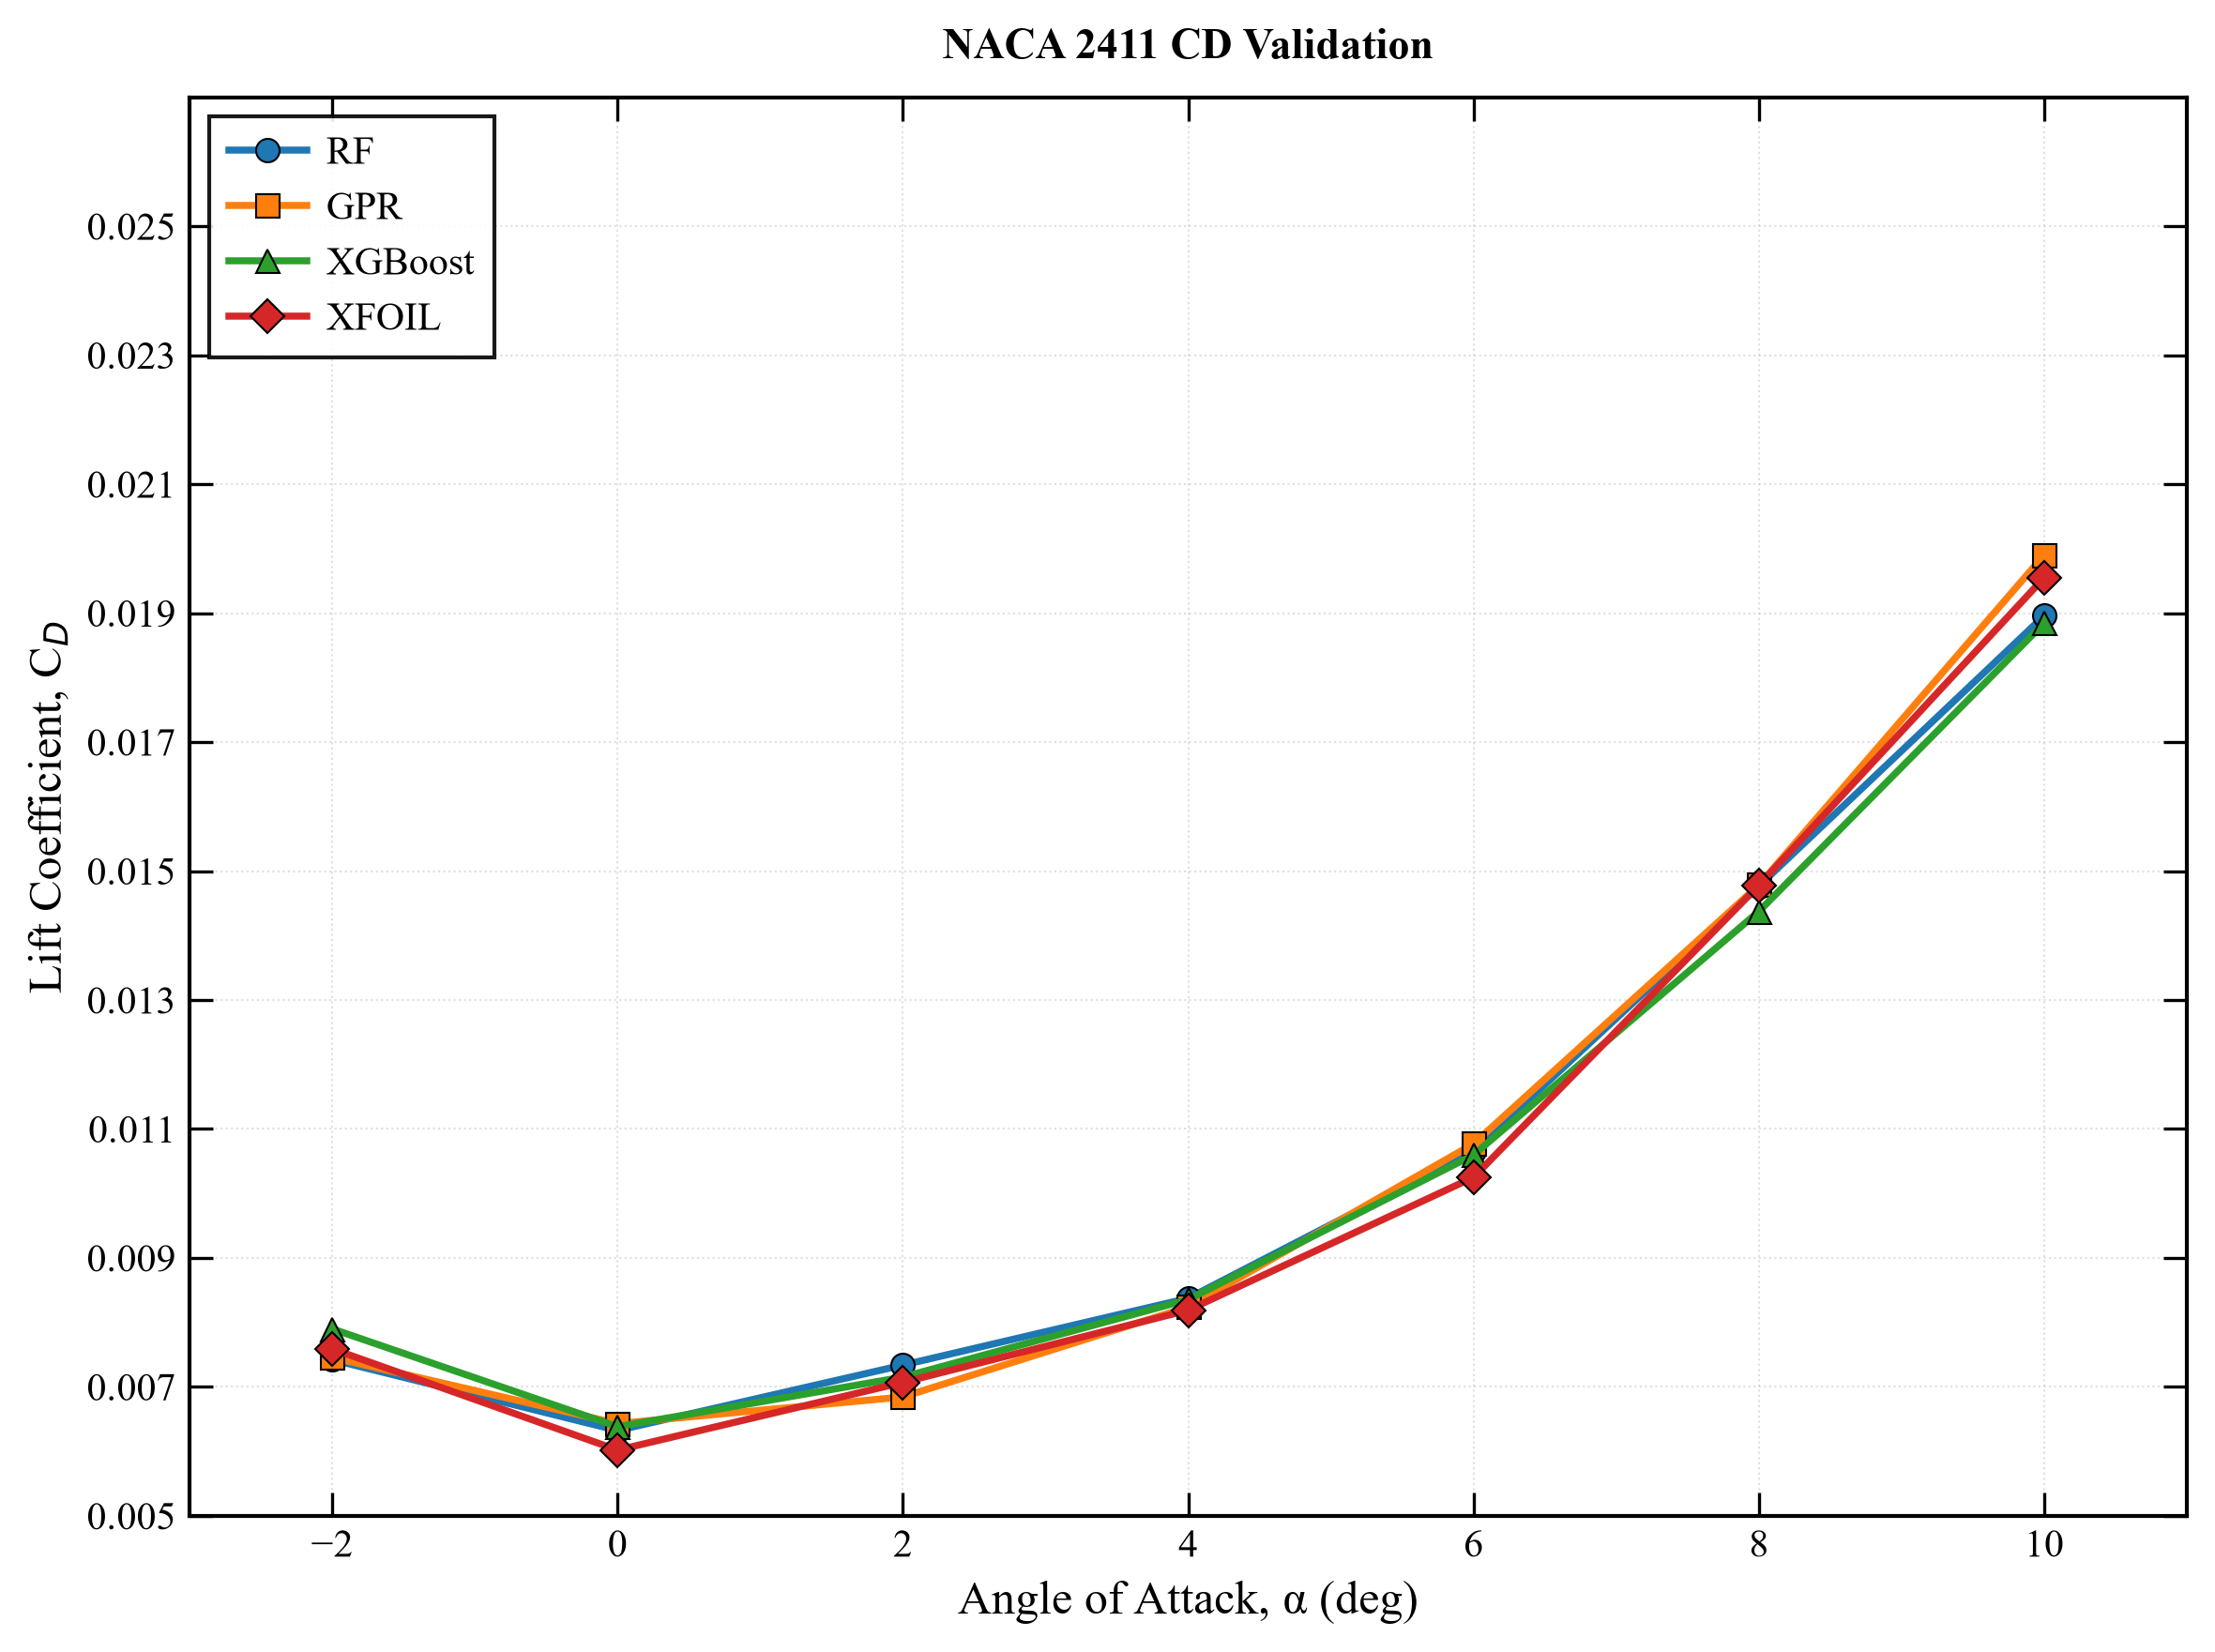

In [4]:
# _-----------------------------------CD-------------------------------
import matplotlib.pyplot as plt
import numpy as np

# Data from the table
AOA = [-2, 0, 2, 4, 6, 8, 10]

data = {
    'RF':      [0.007422,	0.006324,	0.007338,	0.008374,	0.01066,	0.014767,	0.01896],
    'GPR':     [0.007456,	0.006431,	0.006844,	0.008239,	0.01077	,0.014782	,0.019901],
    'XGBoost': [0.0079,	0.006383,	0.007152,	0.008355,	0.010597,	0.014374,	0.018846],
    'XFOIL':   [0.00759,	0.00602,	0.00707,	0.00819,	0.01025,	0.01478,	0.01955],
}

# Scientific journal style settings
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'axes.linewidth': 1.0,
    'lines.linewidth': 1.5,
})

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Color palette suitable for journals (colorblind-friendly)
colors = {
    'RF': '#1f77b4',      # Blue
    'GPR': '#ff7f0e',     # Orange
    'XGBoost': '#2ca02c', # Green
    'XFOIL': '#d62728',   # Red
}

# Markers for different methods
markers = {
    'RF': 'o',
    'GPR': 's',
    'XGBoost': '^',
    'XFOIL': 'D',
}

# Plot each dataset
for method in data.keys():
    ax.plot(AOA, data[method],
            marker=markers[method],
            markersize=6,
            markeredgewidth=0.5,
            markeredgecolor='black',
            linewidth=1.8,
            color=colors[method],
            label=method,
            linestyle='-')

# Axis labels with proper formatting
ax.set_xlabel('Angle of Attack, α (deg)', fontsize=12, fontweight='normal')
ax.set_ylabel('Lift Coefficient, C$_D$', fontsize=12, fontweight='normal')

ax.set_title('NACA 2411 CD Validation', fontsize=11, pad=10, fontweight='bold')

# Set axis limits with padding
ax.set_xlim(-3, 11)
ax.set_ylim(0.005, 0.027)

# Major and minor ticks
ax.set_xticks(np.arange(-2, 11, 2))
ax.set_yticks(np.arange(0.005, 0.027, 0.002))
ax.tick_params(direction='in', top=True, right=True, which='both')
ax.tick_params(axis='both', which='major', length=6, width=0.8)
ax.tick_params(axis='both', which='minor', length=3, width=0.5)

# Grid (light, scientific style)
ax.grid(True, linestyle=':', alpha=0.4, linewidth=0.5)

# Legend - scientific journal style
legend = ax.legend(loc='upper left',
                   frameon=True,
                   fancybox=False,
                   edgecolor='black',
                   framealpha=0.9,
                   borderpad=0.5,
                   handlelength=2.0,
                   handletextpad=0.5,
                   columnspacing=1.0)

# Add a subtle box around the plot
for spine in ax.spines.values():
    spine.set_linewidth(1.0)
    spine.set_color('black')

# Optional: Add horizontal line at CL=0 for reference
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)

# Adjust layout
plt.tight_layout()

# Save as high-quality figure (optional)
# plt.savefig('lift_curve_comparison.pdf', format='pdf', bbox_inches='tight')
# plt.savefig('lift_curve_comparison.png', format='png', bbox_inches='tight', dpi=300)

plt.show()

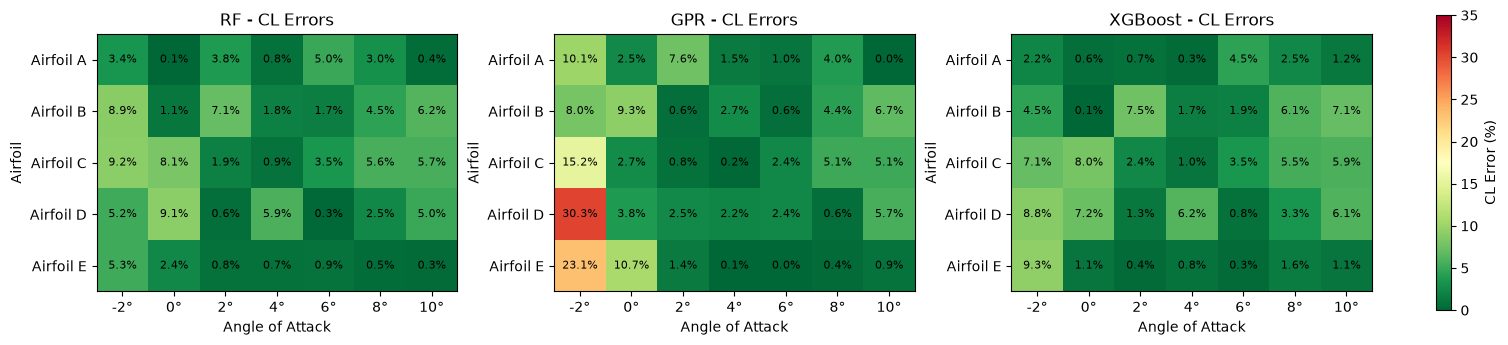

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# CL errors as 2D arrays (5 airfoils × 7 AoAs)
# Rows: A, B, D, E, G
# Columns: -2, 0, 2, 4, 6, 8, 10
cl_rf = np.array([
    [3.35, 0.10, 3.78, 0.81, 5.00, 3.03, 0.42],   # Airfoil A
    [8.90, 1.14, 7.08, 1.82, 1.67, 4.46, 6.24],   # Airfoil B
    [9.16, 8.14, 1.87, 0.88, 3.49, 5.61, 5.70],   # Airfoil D
    [5.21, 9.07, 0.57, 5.87, 0.27, 2.46, 4.97],   # Airfoil E
    [5.28, 2.39, 0.76, 0.69, 0.89, 0.47, 0.30]    # Airfoil G
])

cl_gpr = np.array([
    [10.10, 2.50, 7.61, 1.48, 0.96, 3.95, 0.01],  # Airfoil A
    [8.00, 9.28, 0.56, 2.68, 0.61, 4.36, 6.70],   # Airfoil B
    [15.18, 2.70, 0.75, 0.20, 2.41, 5.14, 5.08],  # Airfoil D
    [30.29, 3.77, 2.55, 2.24, 2.39, 0.64, 5.74],  # Airfoil E
    [23.12, 10.70, 1.38, 0.10, 0.04, 0.41, 0.94]  # Airfoil G
])

cl_xgb = np.array([
    [2.25, 0.56, 0.72, 0.33, 4.48, 2.46, 1.24],   # Airfoil A
    [4.51, 0.05, 7.53, 1.68, 1.86, 6.13, 7.10],   # Airfoil B
    [7.08, 7.95, 2.39, 0.96, 3.53, 5.55, 5.86],   # Airfoil D
    [8.79, 7.25, 1.32, 6.21, 0.80, 3.33, 6.07],   # Airfoil E
    [9.30, 1.09, 0.39, 0.83, 0.28, 1.55, 1.07]    # Airfoil G
])

aoa_labels = ['-2°', '0°', '2°', '4°', '6°', '8°', '10°']
airfoil_labels = ['Airfoil A', 'Airfoil B', 'Airfoil C', 'Airfoil D', 'Airfoil E']

# Create figure for CL
fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

for ax, data, title in zip(axes, [cl_rf, cl_gpr, cl_xgb], ['RF', 'GPR', 'XGBoost']):
    im = ax.imshow(data, cmap='RdYlGn_r', vmin=0, vmax=35)
    ax.set_xticks(np.arange(len(aoa_labels)))
    ax.set_yticks(np.arange(len(airfoil_labels)))
    ax.set_xticklabels(aoa_labels)
    ax.set_yticklabels(airfoil_labels)
    ax.set_title(f'{title} - CL Errors')
    ax.set_xlabel('Angle of Attack')
    ax.set_ylabel('Airfoil')

    # Add text annotations
    for i in range(len(airfoil_labels)):
        for j in range(len(aoa_labels)):
            val = data[i, j]
            text = ax.text(j, i, f'{val:.1f}%',
                          ha='center', va='center',
                          color='black',
                          fontsize=8)

fig.colorbar(im, ax=axes, shrink=0.6, label='CL Error (%)')
plt.savefig('base_airfoil_cl_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

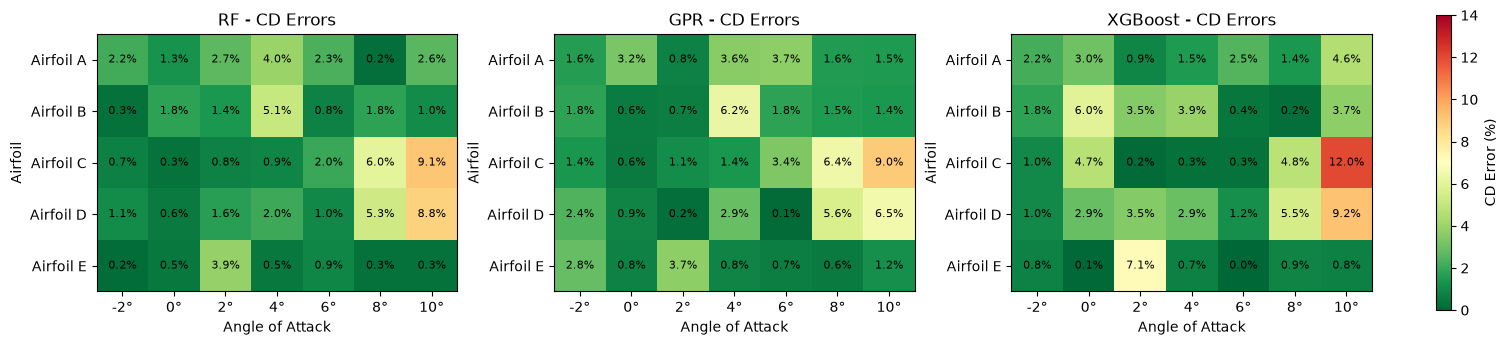

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# CD errors as 2D arrays (5 airfoils × 7 AoAs)
cd_rf = np.array([
    [2.17, 1.29, 2.66, 3.96, 2.33, 0.23, 2.62],   # Airfoil A
    [0.28, 1.75, 1.45, 5.12, 0.82, 1.80, 1.04],   # Airfoil B
    [0.73, 0.33, 0.80, 0.88, 1.98, 6.05, 9.10],   # Airfoil D
    [1.08, 0.57, 1.65, 2.05, 0.97, 5.33, 8.79],   # Airfoil E
    [0.19, 0.50, 3.87, 0.54, 0.88, 0.32, 0.31]    # Airfoil G
])

cd_gpr = np.array([
    [1.61, 3.24, 0.80, 3.57, 3.68, 1.55, 1.52],   # Airfoil A
    [1.76, 0.63, 0.69, 6.24, 1.76, 1.53, 1.44],   # Airfoil B
    [1.37, 0.55, 1.12, 1.41, 3.39, 6.42, 8.98],   # Airfoil D
    [2.41, 0.86, 0.24, 2.87, 0.11, 5.63, 6.51],   # Airfoil E
    [2.82, 0.79, 3.68, 0.85, 0.70, 0.57, 1.18]    # Airfoil G
])

cd_xgb = np.array([
    [2.21, 3.03, 0.88, 1.51, 2.47, 1.43, 4.59],   # Airfoil A
    [1.78, 5.95, 3.49, 3.90, 0.44, 0.22, 3.69],   # Airfoil B
    [1.03, 4.69, 0.16, 0.31, 0.34, 4.81, 12.01],  # Airfoil D
    [1.02, 2.89, 3.49, 2.91, 1.16, 5.49, 9.20],   # Airfoil E
    [0.77, 0.06, 7.14, 0.74, 0.03, 0.86, 0.76]    # Airfoil G
])

# Create figure for CD
fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

for ax, data, title in zip(axes, [cd_rf, cd_gpr, cd_xgb], ['RF', 'GPR', 'XGBoost']):
    im = ax.imshow(data, cmap='RdYlGn_r', vmin=0, vmax=14)
    ax.set_xticks(np.arange(len(aoa_labels)))
    ax.set_yticks(np.arange(len(airfoil_labels)))
    ax.set_xticklabels(aoa_labels)
    ax.set_yticklabels(airfoil_labels)
    ax.set_title(f'{title} - CD Errors')
    ax.set_xlabel('Angle of Attack')
    ax.set_ylabel('Airfoil')

    # Add text annotations
    for i in range(len(airfoil_labels)):
        for j in range(len(aoa_labels)):
            val = data[i, j]
            text = ax.text(j, i, f'{val:.1f}%',
                          ha='center', va='center',
                          color='black',
                          fontsize=8)

fig.colorbar(im, ax=axes, shrink=0.6, label='CD Error (%)')
plt.savefig('base_airfoil_cd_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

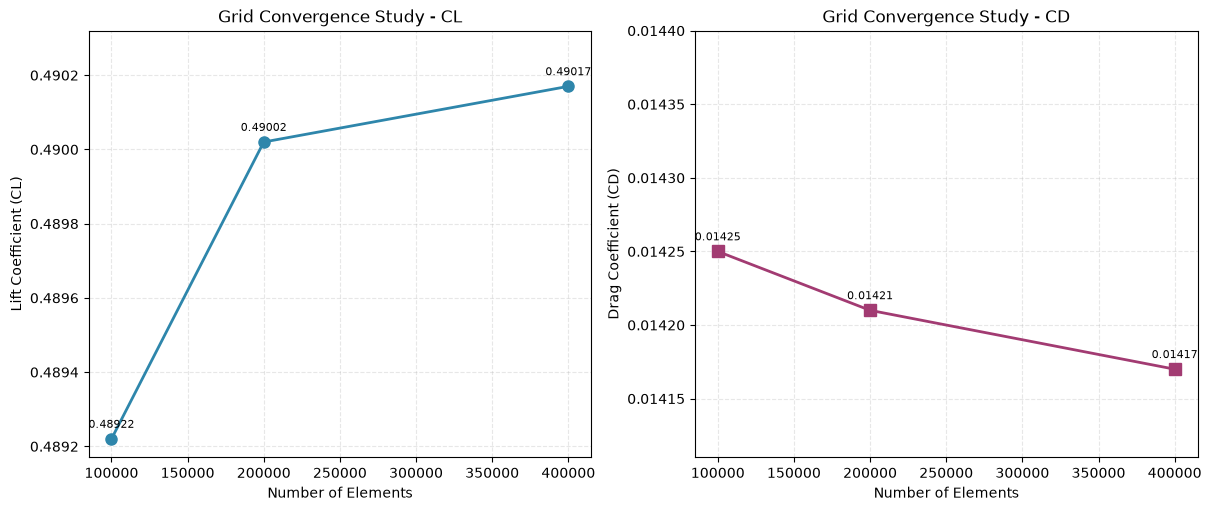

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Data
elements = np.array([100000, 200000, 400000])
cl = np.array([0.48922, 0.49002, 0.49017])
cd = np.array([0.01425, 0.01421, 0.01417])

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

# --- Subplot 1: CL Convergence ---
ax1.plot(elements, cl, 'o-', color='#2E86AB', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Elements')
ax1.set_ylabel('Lift Coefficient (CL)')
ax1.set_title('Grid Convergence Study - CL')
ax1.grid(True, linestyle='--', alpha=0.3)

# Set y-axis limits with padding for labels
cl_min = min(cl) - 0.00005
cl_max = max(cl) + 0.00015
ax1.set_ylim(cl_min, cl_max)

# Add value labels on points with adjusted offset
for x, y in zip(elements, cl):
    ax1.annotate(f'{y:.5f}', (x, y), xytext=(0, 8),
                 textcoords='offset points', ha='center', fontsize=8)

# --- Subplot 2: CD Convergence ---
ax2.plot(elements, cd, 's-', color='#A23B72', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Elements')
ax2.set_ylabel('Drag Coefficient (CD)')
ax2.set_title('Grid Convergence Study - CD')
ax2.grid(True, linestyle='--', alpha=0.3)

# Set y-axis limits with padding for labels
cd_min = min(cd) - 0.00006
cd_max = max(cd) + 0.00015
ax2.set_ylim(cd_min, cd_max)

# Add value labels on points
for x, y in zip(elements, cd):
    ax2.annotate(f'{y:.5f}', (x, y), xytext=(0, 8),
                 textcoords='offset points', ha='center', fontsize=8)

plt.savefig('grid_convergence.png', dpi=300, bbox_inches='tight')
plt.show()